In [ ]:
import sys
from pathlib import Path
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "paths.py").exists():
        sys.path.insert(0, str(_root))
        break
else:
    raise RuntimeError(
        "Could not find Merge project root (paths.py). Run Jupyter with cwd Merge, notebooks/, or attribution/."
    )
import paths


In [5]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


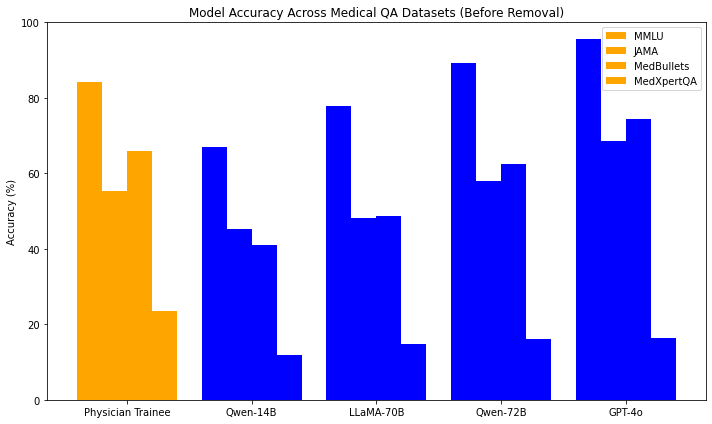

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Model names and corresponding accuracies for each dataset (Before removal)
models = ['Physician Trainee', 'Qwen-14B', 'LLaMA-70B', 'Qwen-72B', 'GPT-4o']
mmlu = [84.2, 66.9, 77.9, 89.3, 95.6]
jama = [55.2, 45.3, 48.1, 57.9, 68.5]
medbullets = [65.8, 40.9, 48.7, 62.4, 74.5]
medxpertqa = [23.5, 12.0, 14.9, 16.2, 16.41]

# X positions for each model
x = np.arange(len(models))
width = 0.2

# Color mapping: orange for Physician Trainee, blue for all LLMs
colors = ['orange'] + ['blue'] * (len(models) - 1)

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - 1.5*width, mmlu, width, label='MMLU', color=colors)
ax.bar(x - 0.5*width, jama, width, label='JAMA', color=colors)
ax.bar(x + 0.5*width, medbullets, width, label='MedBullets', color=colors)
ax.bar(x + 1.5*width, medxpertqa, width, label='MedXpertQA', color=colors)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Model Accuracy Across Medical QA Datasets (Before Removal)')
ax.legend()

plt.tight_layout()
plt.show()


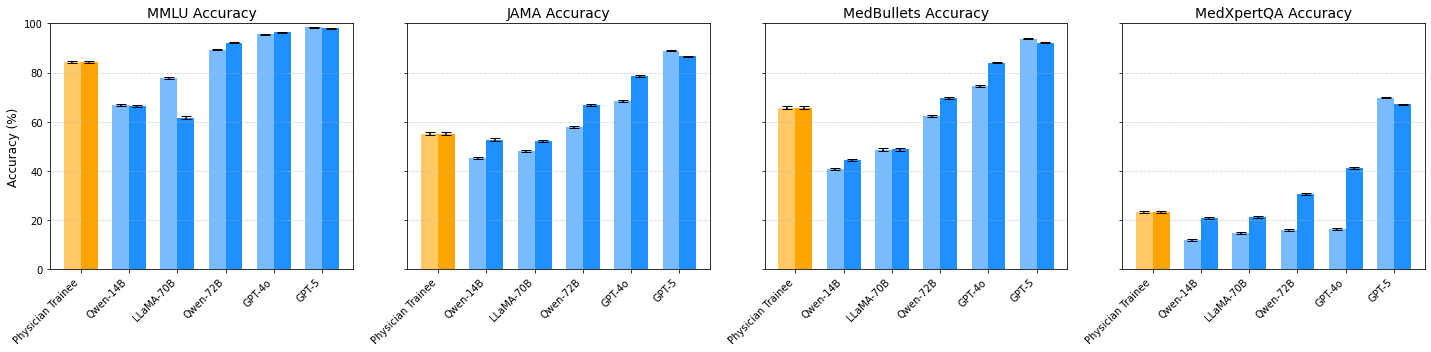

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define model categories and their before/after accuracies with standard deviations
models = ['Physician Trainee', 'Qwen-14B', 'LLaMA-70B', 'Qwen-72B', 'GPT-4o', 'GPT-5']
x = np.arange(len(models))
width = 0.35

datasets = {
    'MMLU': {
        'before':     [84.2, 66.9, 77.9, 89.3, 95.6, 98.4],
        'after':      [84.2, 66.3, 61.7, 92.2, 96.4, 98.0],
        'std_before': [0.36, 0.47, 0.42, 0.31, 0.21, 0.21],
        'std_after':  [0.36, 0.47, 0.49, 0.27, 0.19, 0.21]
    },
    'JAMA': {
        'before':     [55.2, 45.3, 48.1, 57.9, 68.5, 88.9],
        'after':      [55.2, 52.8, 52.2, 66.8, 78.7, 86.6],
        'std_before': [0.49, 0.50, 0.50, 0.50, 0.47, 0.21],
        'std_after':  [0.49, 0.50, 0.50, 0.47, 0.41, 0.21]
    },
    'MedBullets': {
        'before':     [65.8, 40.9, 48.7, 62.4, 74.5, 93.7],
        'after':      [65.8, 44.4, 48.8, 69.6, 84.1, 92.2],
        'std_before': [0.47, 0.49, 0.50, 0.49, 0.44, 0.21],
        'std_after':  [0.47, 0.50, 0.50, 0.46, 0.37, 0.21]
    },
    'MedXpertQA': {
        'before':     [23.5, 12.0, 14.9, 16.2, 16.4, 69.7],
        'after':      [23.5, 21.1, 21.4, 30.8, 41.2, 67.2],
        'std_before': [0.42, 0.33, 0.36, 0.37, 0.37, 0.21],
        'std_after':  [0.42, 0.41, 0.41, 0.46, 0.49, 0.21]
    }
}

# Create a 1x4 subplot
fig, axes = plt.subplots(1, len(datasets), figsize=(20, 5), sharey=True)

for ax, (name, vals) in zip(axes, datasets.items()):
    before = np.array(vals['before'])
    after = np.array(vals['after'])
    std_before = np.array(vals['std_before'])
    std_after = np.array(vals['std_after'])
    
    # Color mapping: orange for Physician Trainee, blue for LLMs
    colors = ['orange'] + ['dodgerblue'] * (len(models) - 1)
    
    # Plot bars with error bars
    ax.bar(x - width/2, before, width, yerr=std_before, capsize=5,
           color=colors, alpha=0.6)
    ax.bar(x + width/2, after, width, yerr=std_after, capsize=5,
           color=colors, alpha=1.0)
    
    # Formatting
    ax.set_title(f'{name} Accuracy', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(0, 100)

# Shared Y-axis label on the first subplot
axes[0].set_ylabel('Accuracy (%)', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()
